In [2]:
!mkdir -p ~/.kaggle && echo "KAGGLE API KEY" > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [3]:
!pip install kaggle --quiet
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:01<00:00, 90.1MB/s]



In [4]:
!unzip -q brain-tumor-mri-dataset.zip -d brain_tumor_data

In [5]:
!rm -rf brain_tumor_data
!unzip -q brain-tumor-mri-dataset.zip -d brain_tumor_data

In [6]:
import os
print(os.listdir("brain_tumor_data"))

['Training', 'Testing']


In [7]:
print(os.listdir("brain_tumor_data/Training"))

['meningioma', 'notumor', 'pituitary', 'glioma']


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_gen = train_datagen.flow_from_directory(
    "brain_tumor_data/Training",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    "brain_tumor_data/Training",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.


In [9]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze pretrained layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 96s 537ms/step - accuracy: 0.8237 - loss: 0.4673 - val_accuracy: 0.8813 - val_loss: 0.3188
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 471ms/step - accuracy: 0.8964 - loss: 0.2829 - val_accuracy: 0.9116 - val_loss: 0.2482
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 479ms/step - accuracy: 0.9065 - loss: 0.2463 - val_accuracy: 0.9107 - val_loss: 0.2374
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 73s 522ms/step - accuracy: 0.9163 - loss: 0.2156 - val_accuracy: 0.9170 - val_loss: 0.2256
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 471ms/step - accuracy: 0.9359 - loss: 0.1683 - val_accuracy: 0.9062 - val_loss: 0.2576
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 473ms/step - accuracy: 0.9404 - loss: 0.1625 - val_accuracy: 0.9250 - val_loss: 0.2068
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 478ms/step - accuracy: 0.9446 - loss: 0.1495 - val_accuracy: 0.9393 - val_loss: 0.1734
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 478ms/step - accuracy: 0.9475 - loss: 0

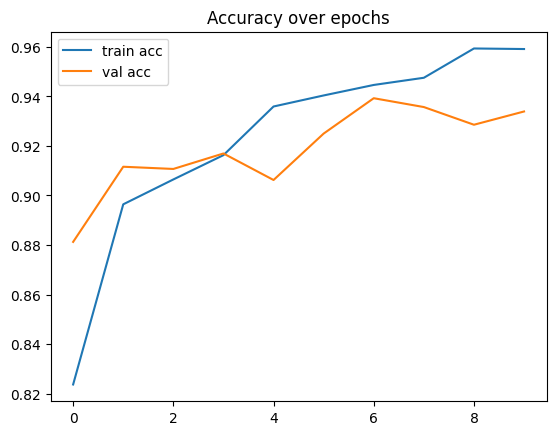

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy over epochs")
plt.show()

In [12]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    "brain_tumor_data/Testing",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

loss, acc = model.evaluate(test_gen)
print(f"Test accuracy: {acc:.2%}")

Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.8431 - loss: 0.7402
Test accuracy: 84.31%


In [13]:
import cv2
import numpy as np

def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Find the last convolutional layer name automatically
for layer in reversed(model.layers):
    if 'conv' in layer.name.lower() and 'expanded' not in layer.name.lower():
        last_conv_layer_name = layer.name
        break

print("Using layer:", last_conv_layer_name)

Using layer: Conv_1_bn


In [19]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [20]:
import cv2
import numpy as np

def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Find the last convolutional layer name automatically
for layer in reversed(model.layers):
    if 'conv' in layer.name.lower() and 'expanded' not in layer.name.lower():
        last_conv_layer_name = layer.name
        break

print("Using layer:", last_conv_layer_name)

Using layer: Conv_1_bn


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


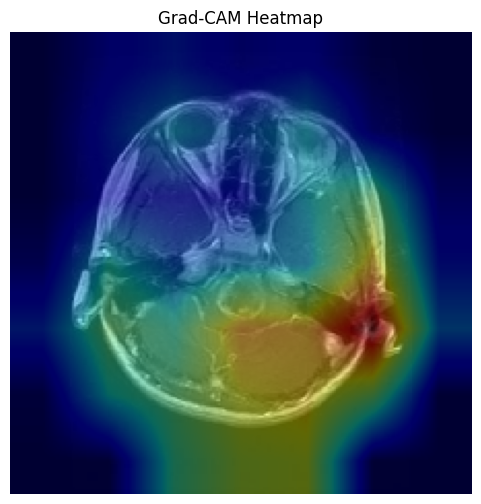

In [21]:
# Get one batch of test images
img_batch, label_batch = next(test_gen)
sample_img = img_batch[0:1]

# Generate the heatmap
heatmap = get_gradcam_heatmap(model, sample_img, last_conv_layer_name)
heatmap_resized = cv2.resize(heatmap, (224, 224))

# Plot original image with heatmap overlay
plt.figure(figsize=(6,6))
plt.imshow(sample_img[0])
plt.imshow(heatmap_resized, cmap='jet', alpha=0.4)
plt.title("Grad-CAM Heatmap")
plt.axis('off')
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step


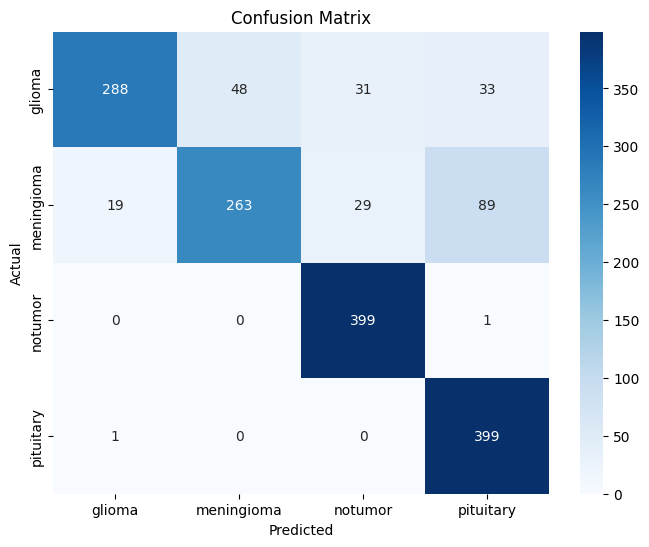

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

test_gen.reset()
predictions = model.predict(test_gen)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [14]:
model.save("brain_tumor_classifier.h5")

In [15]:
model.save('/content/drive/MyDrive/brain_tumor_classifier.h5')

In [16]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/brain_tumor_classifier.h5')